Many problems: batches and changing sizes
=========================================

**When to use:** a training loop solves OT many times, on a batch of point clouds at once or on clouds whose size
changes from one step to the next.

**What you will see:** 16 problems of 10,000 points solved in one call and one by one, and the time of each call
over a sequence of changing sizes, with autotuning on and off.

Source: [plot_many_problems.py](plot_many_problems.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/scale/plot_many_problems.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/scale/plot_many_problems.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import dense_size, images_dir, require_cuda, save, table, timed  # noqa: E402

device = require_cuda()
torch.manual_seed(0)

A batch of problems
-------------------
Inputs of shape (B, N, D) describe B problems, and the loss returns one value per problem. A batch is a
convenience: compare the time of one batched call with the loop over the same problems.

In [ ]:
B, N = 16, 10_000
xb = torch.rand(B, N, 2, device=device)
yb = torch.rand(B, N, 2, device=device) + 0.1
print(dense_size(N, N))
loss = SamplesLoss(blur=0.05, half_cost=True, debias=True, backend="symmetric", autotune=False)
batched = timed("16 problems in one call", lambda: loss(xb, yb))
looped = timed("16 problems one by one", lambda: torch.stack([loss(xb[i], yb[i]) for i in range(B)]))
print(f"values of shape {tuple(batched.shape)}; largest difference between the two: "
      f"{(batched - looped).abs().max().item():.1e}")

Changing sizes and autotuning
-----------------------------
With ``autotune=True`` (the default), the first call for a new size bucket (key n // 32; here the first four calls
meet new buckets) benchmarks kernel configurations, compiling those not yet in the cache; later calls in that
bucket reuse the choice, within the same process. With ``autotune=False`` no call is tuned; compare the warm
calls to judge the benefit on these sizes. If new size buckets keep appearing, turn tuning off.
``pad_to_multiple=k`` pads every cloud to a multiple of k with zero-weight points, so that fewer distinct sizes
reach the tuner, at the cost of the padded points; measure it on your sizes before relying on it.

In [ ]:
sizes = [10_000, 13_000, 17_000, 22_000] * 2
timeline = {}
for autotune in (True, False):
    loss = SamplesLoss(blur=0.05, half_cost=True, debias=True, backend="symmetric", autotune=autotune)
    times = []
    for size in sizes:
        x = torch.rand(size, 2, device=device)
        y = torch.rand(size, 2, device=device) + 0.1
        torch.cuda.synchronize()
        start = time.perf_counter()
        loss(x, y)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
    timeline[autotune] = times
    print(f"autotune={autotune}: " + ", ".join(f"{size:,} points {t:.2f} s" for size, t in zip(sizes, times)))

fig, ax = plt.subplots(figsize=(6.0, 3.9))
table(ax, ["call", "points", "autotune=True", "autotune=False"],
      [[str(i + 1), f"{size:,}", f"{on:.2f} s", f"{off:.2f} s"]
       for i, (size, on, off) in enumerate(zip(sizes, timeline[True], timeline[False]))],
      title=f"seconds per call ({torch.cuda.get_device_name()})")
save(fig, images_dir(__file__), "many_problems")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/scale/images/many_problems.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

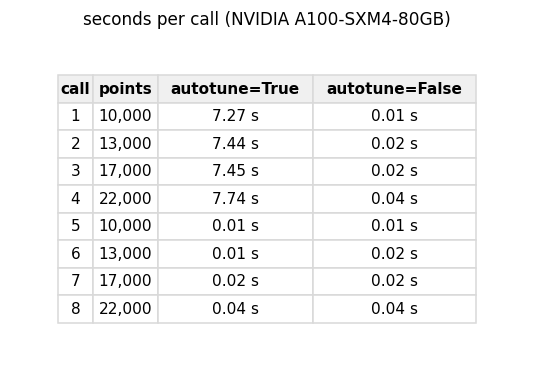